# UMAP + HDBSCAN for Betacov

Embedded using ESM2 8M model, script for embedding from `clustering/betacov` notebooks. Finetuned (NOT base model).

In [506]:
version_dir = "betacov_finetuned"
version_prefix = "BETACOV.from-esm-mlm_CLS-embedded"

In [507]:
import os
import pandas as pd

data_dir = "/panfs/biopan03/prime_ml/prime/data/betacov"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/parquets"

parquet_file = os.path.join(data_dir, "betacoronavirus_seq_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine='fastparquet')

print(embedded_df['variant'].value_counts())
display(embedded_df)

variant
Bat Virus         33
MERSV             21
SARS-CoV-1        15
SARS-CoV-2         3
Pangolin Virus     2
Hibecovirus        1
Name: count, dtype: int64


,seq_id,variant,host,embedding
0,MN996532,Bat Virus,Bat,"[-0.19183712, 0.45011306, 0.49967805, 0.756774..."
1,MG772934,Bat Virus,Bat,"[-0.30005515, 0.65058917, 0.6550717, 0.7039596..."
2,MG772933,Bat Virus,Bat,"[-0.28308988, 0.6491581, 0.66039366, 0.7101965..."
3,KT444582,Bat Virus,Bat,"[-0.23724484, 0.4270615, 0.4050742, 0.73820573..."
4,KY417146,Bat Virus,Bat,"[-0.22176376, 0.4007309, 0.45212156, 0.72232, ..."
...,...,...,...,...
70,AKN24803.1,MERSV,Human,"[-0.25705302, 0.6160833, 0.453325, 0.57901525,..."
71,ASU90527.1,MERSV,Camel,"[-0.2506442, 0.61880815, 0.44428322, 0.5544402..."
72,AKL59401.1,MERSV,Human,"[-0.26611528, 0.62681794, 0.4465537, 0.5578939..."
73,ASY99842.1,MERSV,Human,"[-0.25976172, 0.5912259, 0.4469077, 0.55536854..."


---
## UMAP Parameter Sweep
(doc: https://docs.rapids.ai/api/cuml/stable/api/generated/cuml.manifold.umap/#cuml.manifold.UMAP)

Some more on parameters for UMAP:
- https://umap-learn.readthedocs.io/en/latest/parameters.html
- https://pair-code.github.io/understanding-umap/

We adjust our parameter sweep to include noise fraction. This is the proportion of points that HDBSCAN labels as noise/outliers, meaning they are not assigned to any cluster.

For example: If you have 100 sequences and HDBSCAN labels:
- 80 into clusters
- 20 as -1
- Then: noise_fraction = 20 / 100 = 0.20. This results in a noise_fraction of 0.2, or 20% of the data!

Why does it matter?
| Noise fraction | Interpretation                                  |
| -------------- | ----------------------------------------------- |
| Low            | most points were assigned to clusters           |
| Moderate       | HDBSCAN is being selective                      |
| High           | many points do not fit well into dense clusters |

This will allow us to better make sense of our ARI scores. Some scenarios to help make better sense:
| ARI  | Noise fraction | Interpretation                             |
| ---- | -------------- | ------------------------------------------ |
| High | Low            | Strong result                              |
| High | Very high      | Maybe only a subset clustered well         |
| Low  | High           | Clustering may be too strict               |
| Low  | Low            | Clustering may be forcing poor assignments |

And a more specific example:
| Setting | ARI  | Noise fraction |
| ------- | ---- | -------------- |
| A       | 0.82 | 0.08           |
| B       | 0.83 | 0.47           |

I would usually trust A more, because B is discarding almost half the dataset. Note this is just an additional option that we can use to help determine a plot to use.

In [6]:
import os
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import cupy as cp
from cuml.manifold import UMAP
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def umap_hdbscan_parameter_sweep(parquet_file, embedded_df, n_neighbors_list, min_dist_list, min_samples_list, min_cluster_size_list):
    umap_grid = {
        "n_neighbors": n_neighbors_list,
        "min_dist": min_dist_list,
    }
    umap_param_list = list(ParameterGrid(umap_grid))

    hdbscan_grid = {
        "min_samples": min_samples_list,
        "min_cluster_size": min_cluster_size_list,
    }
    hdbscan_param_list = list(ParameterGrid(hdbscan_grid))

    all_results = []

    # CPU -> GPU
    embedding_matrix = np.vstack(embedded_df["embedding"].values).astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)
    y_true = LabelEncoder().fit_transform(embedded_df["variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # Parameter Sweep (UMAP)
    for umap_params in tqdm(umap_param_list, desc="UMAP sweep"):
        reducer = UMAP(
            n_neighbors=umap_params["n_neighbors"],
            min_dist=umap_params["min_dist"],
            metric="cosine",
            random_state=42,
        )
        X_red = reducer.fit_transform(X_gpu)
        X_red_cpu = cp.asnumpy(X_red)

        umap_df = pd.DataFrame({
            'UMAP 1': X_red_cpu[:, 0],
            'UMAP 2': X_red_cpu[:, 1],
            'Seq ID': embedded_df['seq_id'].values,
            'Variant': embedded_df['variant'].values,
            'Host': embedded_df['host'].values,
        })
        save_as = parquet_file.replace(".parquet", f".umap-nneighbors{umap_params["n_neighbors"]}_mindist{umap_params["min_dist"]}.parquet")
        umap_df.to_parquet(save_as, engine='fastparquet')

        # Parameter Sweep (HDBSCAN)
        for hdbscan_params in tqdm(hdbscan_param_list, leave=False):
            clusterer = HDBSCAN(
                min_samples=hdbscan_params["min_samples"],
                min_cluster_size=hdbscan_params["min_cluster_size"],
            )

            labels = clusterer.fit_predict(X_red)
            ari = float(adjusted_rand_score(y_true_gpu, labels))
            noise_fraction = float(cp.mean(labels == -1))

            non_noise_mask = labels != -1
            valid_cluster_labels = labels[non_noise_mask]
            
            n_non_noise_samples = int(cp.sum(non_noise_mask))
            n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

            # silhouette needs at least two clusters AND
            # avoids the case where every non-noise point is its own cluster
            if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
                silhouette_avg = float(silhouette_score(X_red[non_noise_mask], valid_cluster_labels,  metric="cosine"))
            else:
                silhouette_avg = np.nan            

            all_results.append({
                "n_neighbors": umap_params["n_neighbors"],
                "min_dist": umap_params["min_dist"],
                "min_samples": hdbscan_params["min_samples"],
                "min_cluster_size": hdbscan_params["min_cluster_size"],
                "ari": ari,
                "noise_fraction": noise_fraction,
                "silhouette": silhouette_avg,
                "n_clusters": n_non_noise_clusters,
            })
            
        # cleanup
        del X_red
        cp._default_memory_pool.free_all_blocks()

    # Final results of both parameter sweeps
    full_results_df = pd.DataFrame(all_results) # All results
    return full_results_df

/panfs/biopan03/prime_ml/miniconda3/envs/blackwell_prime/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%%time

data_dir = "/panfs/biopan03/prime_ml/prime/data/betacov"
sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/param_sweeps"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/parquets"

umap_grid = {
    "n_neighbors": list(range(2,74)),
    "min_dist": [0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
}

hdbscan_grid = {
    "min_samples": range(1, 26),
    "min_cluster_size": range(2, 26),
}

parquet_file = os.path.join(data_dir, "betacoronavirus_seq_from-esm-mlm_CLS-embedded.parquet")
embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")

parquet_file_name = os.path.join(parquet_dir, version_dir, f"{version_prefix}.parquet")

full_results_umap_df = umap_hdbscan_parameter_sweep(
    os.path.join(parquet_dir, version_dir, parquet_file_name),
    embedded_df, 
    umap_grid["n_neighbors"],
    umap_grid["min_dist"],
    hdbscan_grid["min_samples"],
    hdbscan_grid["min_cluster_size"],
)

full_results_umap_df.to_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"), index=False)

UMAP sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 504/504 [23:54<00:00,  2.85s/it]


CPU times: user 23min 22s, sys: 23.1 s, total: 23min 46s
Wall time: 23min 55s


---
## Plotting

In [508]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import cupy as cp
from cuml.cluster import HDBSCAN
from cuml.preprocessing import LabelEncoder
from cuml.metrics.cluster import adjusted_rand_score, silhouette_score

def get_coord_cols(df):
    if {"t-SNE component 1", "t-SNE component 2"}.issubset(df.columns):
        return "t-SNE component 1", "t-SNE component 2", "t-SNE"
    elif {"UMAP 1", "UMAP 2"}.issubset(df.columns):
        return "UMAP 1", "UMAP 2", "UMAP"
    else:
        raise ValueError("Could not find t-SNE or UMAP coordinate columns.")

def get_hdbscan_values(parquet_file, min_samples, min_cluster_size):
    embedded_df = pd.read_parquet(parquet_file, engine="fastparquet")
    x_col, y_col, method_name = get_coord_cols(embedded_df)
    
    # CPU -> GPU
    embedding_matrix = embedded_df[[x_col, y_col]].values.astype(np.float32)
    X_gpu = cp.asarray(embedding_matrix)

    y_true = LabelEncoder().fit_transform(embedded_df["Variant"].values)
    y_true_gpu = cp.asarray(y_true)

    # GPU HDBSCAN
    clusterer = HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,
    )

    labels_gpu = clusterer.fit_predict(X_gpu)

    # GPU metrics
    ari = float(adjusted_rand_score(y_true_gpu, labels_gpu))
    noise_fraction = float(cp.mean(labels_gpu == -1))

    non_noise_mask = labels_gpu != -1
    valid_cluster_labels = labels_gpu[non_noise_mask]

    n_non_noise_samples = int(cp.sum(non_noise_mask))
    n_non_noise_clusters = int(cp.unique(valid_cluster_labels).size)

    # silhouette needs at least two clusters AND
    # avoids the case where every non-noise point is its own cluster
    if n_non_noise_clusters > 1 and n_non_noise_samples > n_non_noise_clusters:
        silhouette_avg = float(silhouette_score(X_gpu[non_noise_mask], valid_cluster_labels,  metric="cosine"))
    else:
        silhouette_avg = np.nan                

    print(
        f"min_samples = {min_samples}, "
        f"min_cluster_size = {min_cluster_size}: "
        f"ARI = {ari:.2f}, "
        f"Silhouette = {silhouette_avg:.2f}, "
        f"Clusters = {n_non_noise_clusters}, "
        f"Noise = {noise_fraction:.2%}"
    )

    # GPU -> CPU for pandas
    labels = cp.asnumpy(labels_gpu)

    truth_table_percent = pd.crosstab(
        embedded_df["Variant"],
        labels,
        rownames=["Ground Truth"],
        colnames=["Predicted Clusters"],
        normalize="index",
    )
    truth_table_percent = (truth_table_percent * 100).round(2)

    plot_df = pd.DataFrame({
        x_col: embedded_df[x_col].values,
        y_col: embedded_df[y_col].values,
        'Cluster': labels,
        'Seq ID': embedded_df['Seq ID'],
        'Variant': embedded_df['Variant'],
        'Host': embedded_df['Host'],
    })

    save_as = parquet_file.replace(
        ".parquet",
        f".HDBSCAN-ms{min_samples}_mcs{min_cluster_size}-ari{ari:.2f}_sc{silhouette_avg:.2f}_noise{noise_fraction:.2f}"
    )
    plot_df.to_parquet(f"{save_as}.parquet", engine="fastparquet", index=False)

    del X_gpu, labels_gpu
    cp.get_default_memory_pool().free_all_blocks()

    return plot_df, truth_table_percent, save_as

def plot_groundtruth_prediction_1x2(plot_df, save_as, plot_dir, annotation_labels, x_min_width_buffer, x_max_width_buffer, y_min_height_buffer, y_max_height_buffer, color_map, cluster_color_palette_order=None):
    marker_size = 250

    # Define a host shape palette
    unique_hosts = np.unique(plot_df['Host'])
    host_marker_palette = ['o', '^', 's', '*', 'P', 'D', 'v', 'p', '.', '>', '<', 'd', 'H', 'h', '8']   # Use only filled markers
    host_marker_dict = {label: marker for label, marker in zip(unique_hosts, host_marker_palette)}
    
    # Define a variant color palette
    unique_variants = np.unique(plot_df['Variant'])
    variant_color_palette = sns.color_palette(color_map, n_colors=len(unique_variants)) 
    variant_color_dict = {label: color for label, color in zip(unique_variants, variant_color_palette)}

    # Define a cluster color palette
    unique_clusters = np.unique(plot_df["Cluster"])
    non_noise_clusters = unique_clusters[unique_clusters != -1]

    cluster_color_palette = sns.color_palette(color_map, n_colors=len(non_noise_clusters))

    if cluster_color_palette_order is not None:
        cluster_color_palette = sns.color_palette(color_map)
        cluster_color_palette = [cluster_color_palette[i] for i in cluster_color_palette_order]

    cluster_color_dict = {label: color for label, color in zip(non_noise_clusters, cluster_color_palette)}
    cluster_color_dict[-1] = 'black'  # Set outliers to x

    sns.set_style('ticks')
    sns.set_context("poster")
    fig, axs = plt.subplots(1, 2, figsize=(20.25, 6.5), sharey=True)
    fig.subplots_adjust(wspace=0.05)  # Reduce the horizontal space between subplots

    x_col, y_col, method_name = get_coord_cols(plot_df)
    #####################################################

    # Scatterplot
    sns.scatterplot(
        data=plot_df,
        x=x_col, y=y_col,
        hue='Variant', palette=variant_color_dict, 
        style='Host', markers=host_marker_dict,
        s=marker_size, alpha=0.5, edgecolor=".2", linewidth=1,
        ax=axs[0]
    )

    # Outline points in black 
    annotate_df = plot_df[plot_df['Seq ID'].isin(annotation_labels)]
    sns.scatterplot(
        data=annotate_df,
        x=x_col, y=y_col,
        style='Host', markers=host_marker_dict,  
        s=marker_size, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[0]
    )

    # Annotate points
    for idx, row in annotate_df.iterrows():
        if row['Seq ID'] in annotation_labels:  # Only annotate specified labels
            x, y = row[x_col], row[y_col]
            if row['Seq ID'] == 'MN908947': label = "WT"
            elif row['Seq ID'] == 'MN996532': label = "RaTG-13"
            else: label = row['Seq ID']
            x_offset, y_offset = annotation_labels.get(row['Seq ID']) 
                        
            axs[0].annotate(
                label, 
                (x, y), xytext=(x_offset, y_offset), textcoords='offset points',
                color='k',
                fontsize=12, fontweight='bold', ha='center', va='center',
                arrowprops=dict(arrowstyle="-", color='k', lw=1)
            )

    # axs[0].set_title(f"Ground Truth ({len(unique_variants)} variants)", ha='center', fontweight='bold')
    axs[0].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))
    axs[0].set_ylim(plot_df[y_col].min()-y_min_height_buffer, plot_df[y_col].max()+y_max_height_buffer),

    # Legend 
    host_handles = [
        plt.Line2D([0], [0], marker=host_marker_dict[host], color='black', linestyle='none', label=f'{host}')
        for host in unique_hosts
    ]
    variant_handles = [
        plt.Line2D([0], [0], color=variant_color_dict[variant], label=f'{variant}')
        for variant in unique_variants
    ]
    host_legend = axs[0].legend(handles=host_handles, ncol=5, columnspacing=1, handletextpad=0, loc="upper center", fontsize=14)
    variant_legend = axs[0].legend(handles=variant_handles, ncol=1, loc="lower left", fontsize=10)
    axs[0].add_artist(host_legend)
    
    # #####################################################

    # Scatterplot for non-outliers
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] != -1],  # Exclude outliers
        x=x_col, y=y_col,
        hue='Cluster', palette=cluster_color_dict,
        style='Host', markers=host_marker_dict, 
        s=marker_size, alpha=0.5, edgecolor=".2", linewidth=1,
        ax=axs[1]
    )

    # Scatterplot for outliers (Cluster = -1)
    sns.scatterplot(
        data=plot_df[plot_df['Cluster'] == -1],  # Select only outliers
        x=x_col, y=y_col,
        marker='x',
        s=marker_size-100, color='black', linewidth=2,
        ax=axs[1]
    )

    # Outline points in black 
    annotate_df = plot_df[plot_df['Seq ID'].isin(annotation_labels)]
    sns.scatterplot(
        data=annotate_df[annotate_df['Cluster'] != -1],
        x=x_col, y=y_col,
        style='Host', markers=host_marker_dict,  
        s=marker_size, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[1]
    )

    sns.scatterplot(
        data=annotate_df[annotate_df['Cluster'] == -1],
        x=x_col, y=y_col,
        style='Host', markers=host_marker_dict,  
        s=marker_size-100, edgecolor='black', facecolor='none', linewidth=1.5,
        ax=axs[1]
    )

    # Annotate points
    for idx, row in annotate_df.iterrows():
        if row['Seq ID'] in annotation_labels:  # Only annotate specified labels
            x, y = row[x_col], row[y_col]
            if row['Seq ID'] == 'MN908947': label = "WT"
            elif row['Seq ID'] == 'MN996532': label = "RaTG-13"
            else: label = row['Seq ID']
            x_offset, y_offset = annotation_labels.get(row['Seq ID']) 
                        
            axs[1].annotate(
                label, 
                (x, y), xytext=(x_offset, y_offset), textcoords='offset points',
                color='k',
                fontsize=12, fontweight='bold', ha='center', va='center',
                arrowprops=dict(arrowstyle="-", color='k', lw=1)
            )


    # axs[1].set_title(f"Predicted ({len(unique_clusters[unique_clusters != -1])} clusters)", ha='center', fontweight='bold')
    axs[1].set_xlim((plot_df[x_col].min()-x_min_width_buffer, plot_df[x_col].max()+x_max_width_buffer))

    # Legend 
    host_handles = [
        plt.Line2D([0], [0], marker=host_marker_dict[host], color='black', linestyle='none', label=f'{host}')
        for host in unique_hosts
    ]
    cluster_handles = [plt.Line2D([0], [0], marker='x', color='black', linestyle='none', label='Outliers')]
    cluster_handles += [
        plt.Line2D([0], [0], color=cluster_color_dict[cluster], label=f'Cluster {cluster}')
        for cluster in unique_clusters if cluster != -1
    ]
    host_legend = axs[1].legend(handles=host_handles, ncol=5, columnspacing=1, handletextpad=0, loc="upper center", fontsize=14)
    cluster_legend = axs[1].legend(handles=cluster_handles, ncol=1, loc="lower left", fontsize=10)
    axs[1].add_artist(host_legend)

    #####################################################
    base = os.path.splitext(os.path.basename(save_as))[0]  
    filename = f"{base}"
    
    save_as = os.path.join(plot_dir, filename)  
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')
    plt.show()

In [509]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def ari_sc_heatmap(results_df, save_as, plot_dir):

    # Convert to DataFrame
    df = results_df.copy()

    # Pivot matrices
    ari_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='ari')
    silhouette_matrix = df.pivot(index='min_samples', columns='min_cluster_size', values='silhouette')

    # Plot heatmaps
    sns.set_style('ticks')
    sns.set_context("talk")
    fig, axs = plt.subplots(2, 1, figsize=(20, 20))

    sns.heatmap(ari_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[0], vmin=-0.19, vmax=1)
    axs[0].set_title("Adjusted Rand Index (ARI)")
    axs[0].set_xlabel("min_cluster_size")
    axs[0].set_ylabel("min_samples")

    max_ari = ari_matrix.max().max()  # Get the max ARI value

    for i in range(ari_matrix.shape[0]):  # min_sample (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[0].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    sns.heatmap(silhouette_matrix, annot=True, annot_kws={"size": 16}, fmt=".2f", linewidth=.5, cmap="RdBu", ax=axs[1], vmin=-0.19, vmax=1)
    axs[1].set_title("Silhouette Coefficient")
    axs[1].set_xlabel("min_cluster_size")
    axs[1].set_ylabel("min_samples")

    for i in range(ari_matrix.shape[0]):  # min_samples (rows)
        for j in range(ari_matrix.shape[1]):  # min_cluster_size (cols)
            if np.isclose(ari_matrix.iloc[i, j], max_ari):  # Safe float comparison
                axs[1].add_patch(
                    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=3)
                )

    base = os.path.splitext(os.path.basename(parquet_file))[0]
    filename = f"{base}.HDBSCAN_heatmap"
    
    save_as = os.path.join(plot_dir, filename)
    plt.savefig(f"{save_as}.pdf", format="pdf", dpi=300, bbox_inches='tight')
    plt.savefig(f"{save_as}.png", format="png", dpi=300, bbox_inches='tight')

    plt.show()

### n_neighbors and min_dist
Let's take a look at several n_neighbors and min_dist options. 

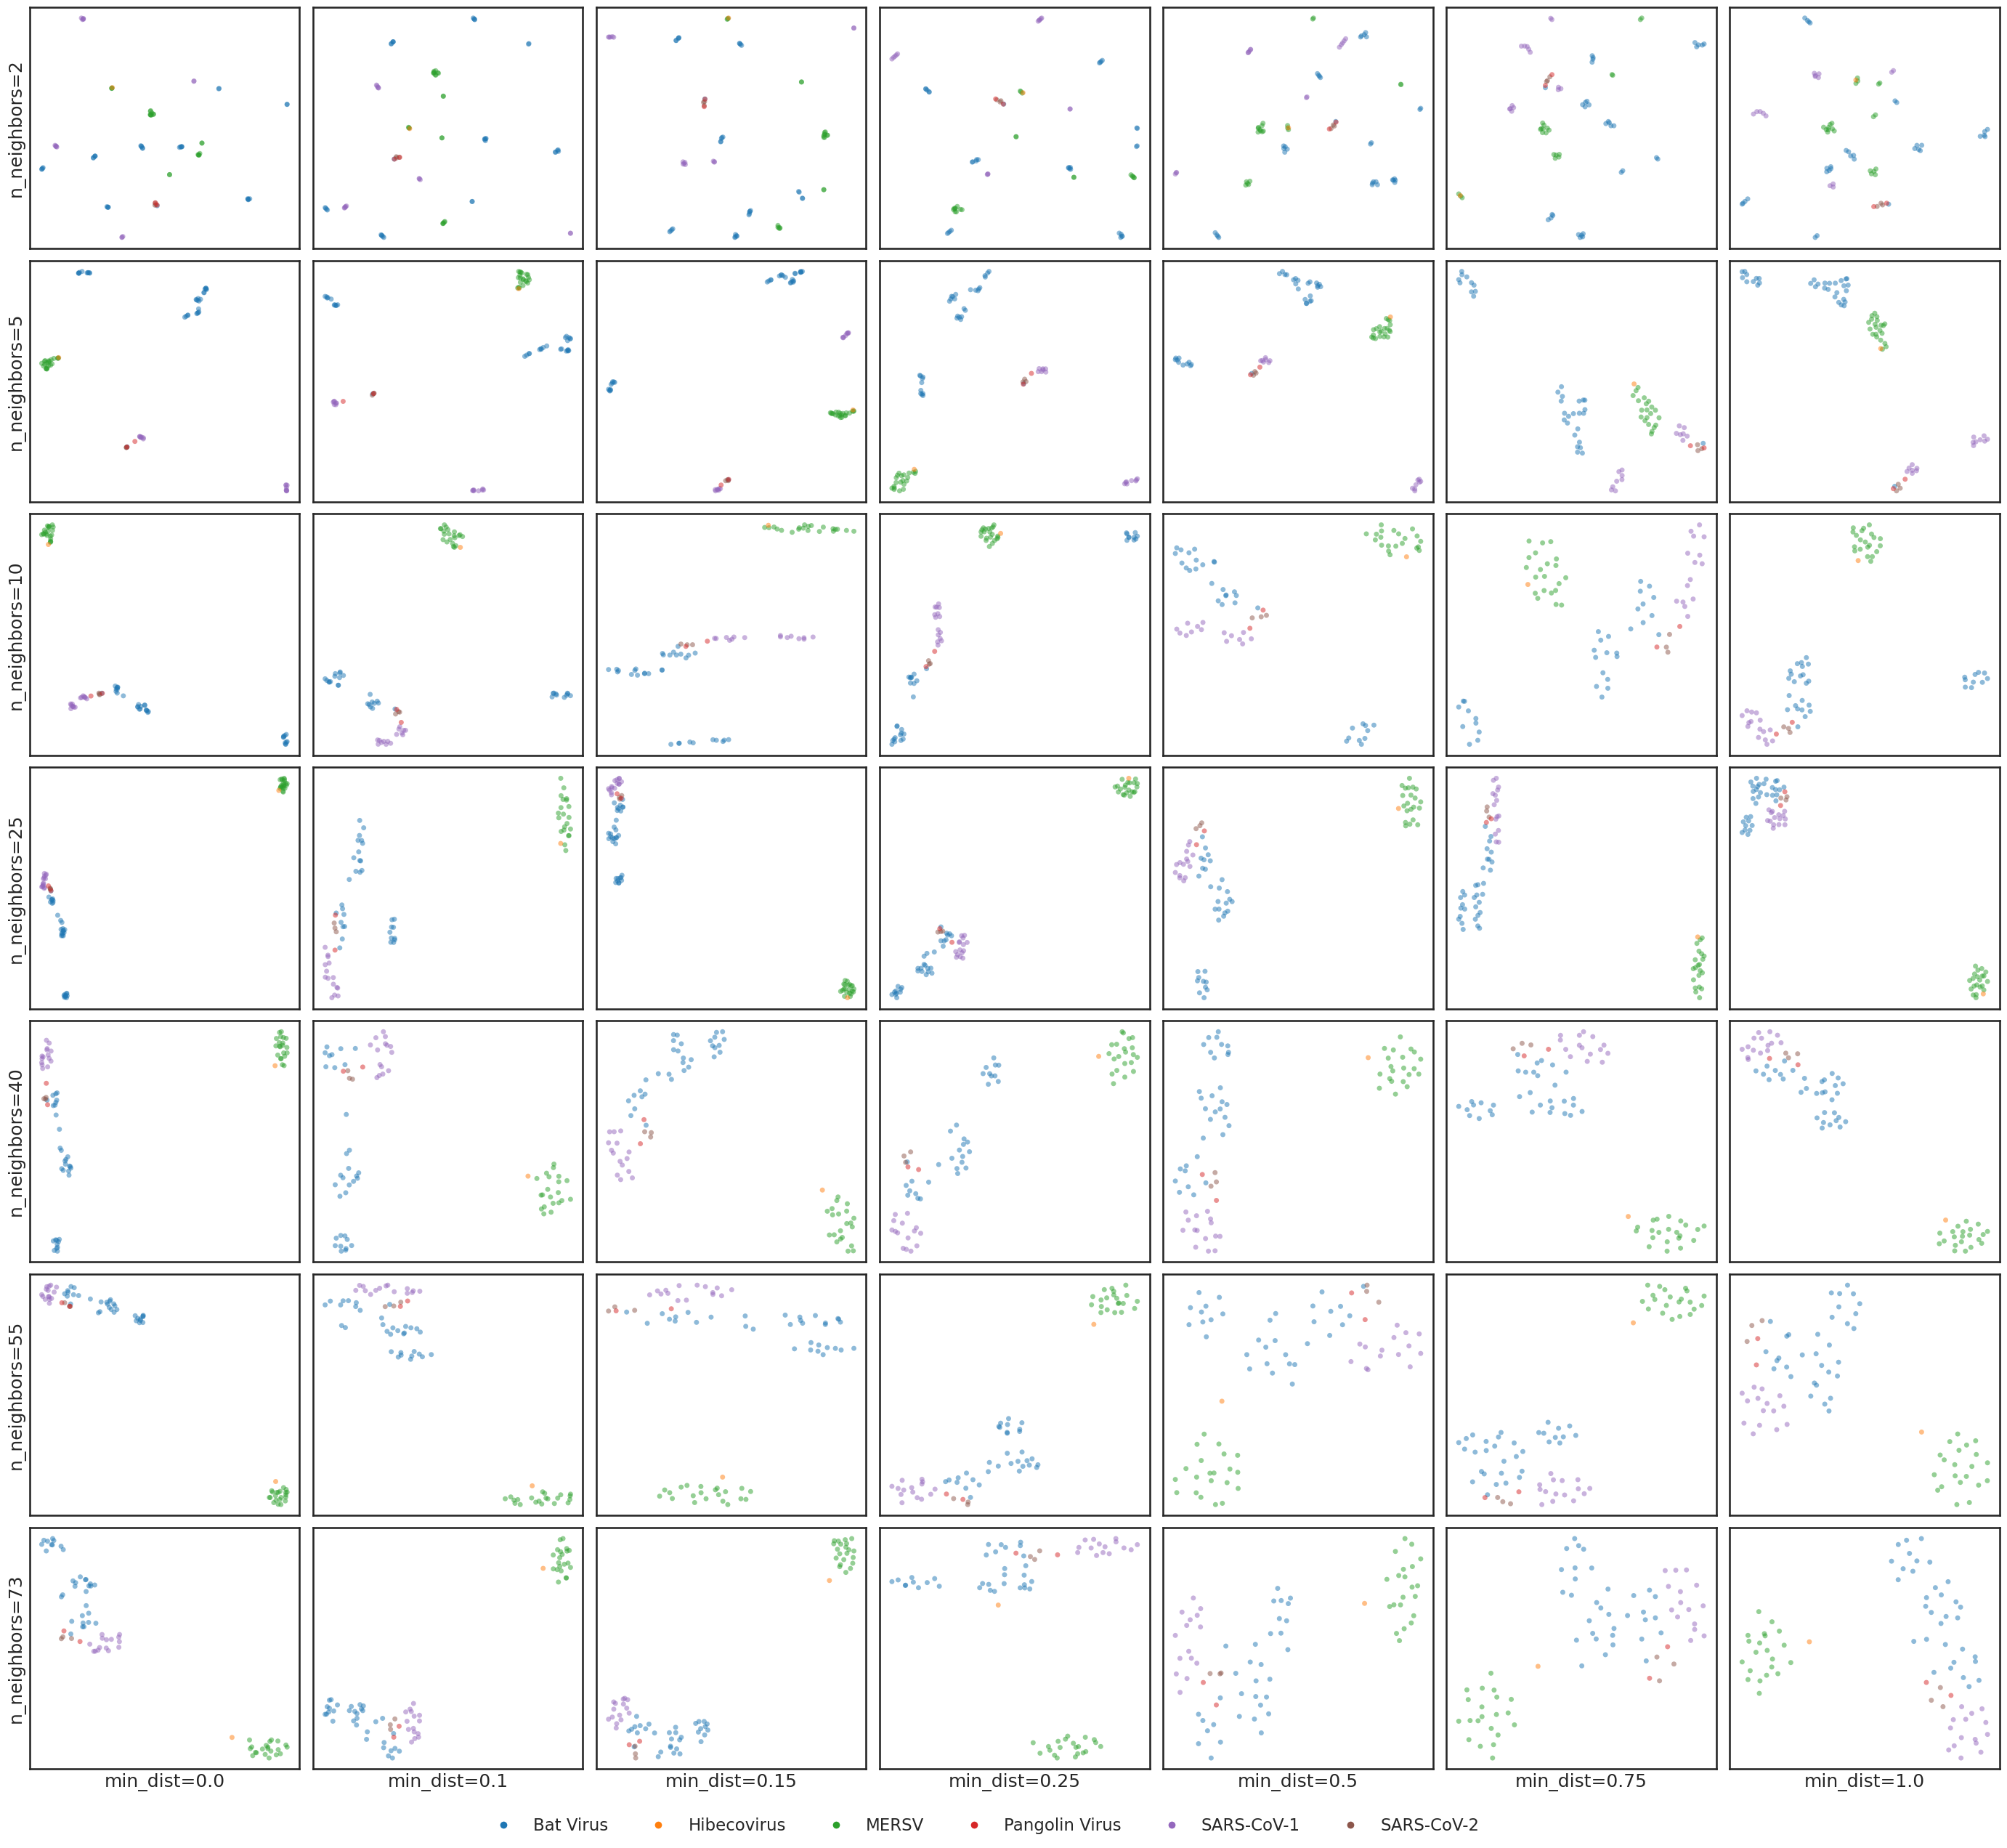

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_umap_grid(parquet_dir, version_dir, version_prefix, n_neighbors_list, min_dist_list):
    n_rows = len(n_neighbors_list)
    n_cols = len(min_dist_list)

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows),
        squeeze=False
    )

    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    for i, n_neighbors in enumerate(n_neighbors_list):
        for j, min_dist in enumerate(min_dist_list):
            ax = axes[i, j]

            parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")
            plot_df = pd.read_parquet(parquet_file, engine="fastparquet")

            unique_variants = np.unique(plot_df["Variant"])
            variant_color_palette = sns.color_palette("tab10", n_colors=len(unique_variants))
            variant_color_dict = {
                label: color for label, color in zip(unique_variants, variant_color_palette)
            }
            variant_colors = [variant_color_dict[v] for v in plot_df["Variant"]]

            ax.scatter(
                plot_df["UMAP 1"],
                plot_df["UMAP 2"],
                c=variant_colors,
                s=25,
                alpha=0.5,
                edgecolor="none",
                linewidth=0,
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # Only show y-axis label on first column
            if j == 0:
                ax.set_ylabel(f"n_neighbors={n_neighbors}")

            # Only show x-axis label on bottom row
            if i == n_rows - 1:
                ax.set_xlabel(f"min_dist={min_dist}")

    # One shared legend
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=variant_color_dict[v],
            markersize=8,
        )
        for v in unique_variants
    ]

    fig.legend(
        handles,
        unique_variants,
        loc="lower center",
        ncol=len(unique_variants),
        frameon=False,
        bbox_to_anchor=(0.5, 0.075),
    )

    plt.show()

# Run
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/parquets"

plot_umap_grid(
    parquet_dir,
    version_dir,
    version_prefix,
    n_neighbors_list=[2, 5, 10, 25, 40, 55, 73],
    min_dist_list=[0.0, 0.1, 0.15, 0.25, 0.5, 0.75, 1.0],
)

Let's add some additional columns to help us choose the "best" plot. First, our parts:

**Adjusted Rand Index**
- AKA "How closely do cluster labels match known lables (ground truth)?"
- We will have this as our primary metric, because we prioritize closeness to ground truth labels. 

**Noise Fraction**
- AKA "How much data did HDBSCAN throw away?"
- Noise fraction is bad. More noise = worse plot. To make this a penalty, we need to make it `1 - noise_fraction`. Then it represents raction of points actually assigned to clusters. Here are some examples why:

    | Noise fraction | `1 - noise_fraction` | Meaning             |
    | -------------: | -------------------: | ------------------- |
    |           0.00 |                 1.00 | no penalty          |
    |           0.25 |                 0.75 | mild penalty        |
    |           0.50 |                 0.50 | strong penalty      |
    |           0.80 |                 0.20 | very strong penalty |

**Silhouette Coefficient**
- AKA "Are predicted clusters separated/compact? Cleaner visual clusters?"
- SC ranges from -1 to 1. Because our score is multiplicative, we should scale it from 0 to 1 instead with `(silhouette + 1) / 2`. Here are some examples:

    | Silhouette | Scaled silhouette | Interpretation |
    | ---------: | ----------------: | -------------- |
    |       -1.0 |              0.00 | very bad       |
    |        0.0 |              0.50 | weak/neutral   |
    |        0.5 |              0.75 | good           |
    |        1.0 |              1.00 | excellent      |

**Cluster count**
- AKA "Are there too few or too many clusters than labels?"
- We want to penalize having too few or too many clusters relative to the target number of known labels.
- First we need to distance between the number of known clusters and predicted clusters: `abs(n_clusters - target_n_clusters)`
- Then we need to make it on the scale of 0 to 1: `np.exp(-cluster_alpha * distance_from_target_n_clusters)`

Ignore below, that is more exploratory

<strike>All together this will be represented as
- `score = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha) * cluster_count_penalty)`
- We can control the strength of each part with an alpha variable.
    - 0 - ignore      
    - 0.5 - weak effect   
    - 1 - normal effect 
    - 2 - strong effect 

We can think of it as 
- `score = label agreement × clustered coverage × visual cluster quality × cluster quantity agreement`</strike>

We are just going to match what we did in the paper, which is basically try to find the best ARI, then SC score. We'll leave the `ari_noise_score` as an idea, but ignore it for the paper.

In [512]:
import os
import pandas as pd

sweep_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/param_sweeps"

full_results_umap_df = pd.read_csv(os.path.join(sweep_dir, version_dir, f"{version_prefix}-umap_hdbscan-parameter_sweep.csv"))
scored_results_df = full_results_umap_df.copy()

In [513]:
# Make sure ari between -1 and 1...
invalid_ari_mask = (
    scored_results_df["ari"].notna()
    & ~scored_results_df["ari"].between(-1, 1)
)

print("Invalid ari rows:", invalid_ari_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_ari_mask].copy()

print("Rows after:", len(scored_results_df))

# Make sure silhouette between -1 and 1...
invalid_silhouette_mask = (
    scored_results_df["silhouette"].notna()
    & ~scored_results_df["silhouette"].between(-1, 1)
)

print("Invalid silhouette rows:", invalid_silhouette_mask.sum())
print("Rows before:", len(scored_results_df))

# Drop invalid rows
scored_results_df = scored_results_df.loc[~invalid_silhouette_mask].copy()

print("Rows after:", len(scored_results_df))

Invalid ari rows: 0
Rows before: 302400
Rows after: 302400
Invalid silhouette rows: 0
Rows before: 302400
Rows after: 302400


In [514]:
import numpy as np

# Grab ARI score
ari = scored_results_df["ari"]

# Create a noise penalty
noise_alpha = 2  # higher = stronger penalty
noise_penalty = (1 - scored_results_df["noise_fraction"])

# # Create a cluster count penalty
# n_clusters = scored_results_df["n_clusters"]
# target_n_clusters = 6 # one for each ground truth
# cluster_alpha = 0.25

# distance_from_target_n_clusters = abs(n_clusters - target_n_clusters)
# cluster_count_penalty = np.exp(-cluster_alpha * distance_from_target_n_clusters) # e^(-x), or 1/(e^x)

# # Create scaled silhouette coefficient
# silhouette_scaled = (scored_results_df["silhouette"] + 1) / 2
# silhouette_alpha = 0.25

# Final score equations
scored_results_df["ari_noise_score"] = (ari * (noise_penalty**noise_alpha))
# scored_results_df["ari_noise_silhouette_score"] = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha))
# scored_results_df["ari_noise_silhouette_clusterct_score"] = (ari * (noise_penalty**noise_alpha) * (silhouette_scaled**silhouette_alpha) * cluster_count_penalty)

### Best result within each UMAP setting, based on just ARI and SC

In [515]:
summary_df = (
    scored_results_df
    .sort_values(by=["ari", "silhouette"], ascending=[False, False])
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print(f"Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df.sort_values(
        by=["best_ari", "best_silhouette"],
        ascending=[False, False]
    ).head(5)
).reset_index(drop=True)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score
0,5,0.00,1,14,0.872938,0.280000,0.850790,2,0.452531
1,5,0.25,1,14,0.872938,0.280000,0.618346,2,0.452531
2,71,0.75,1,3,0.851129,0.000000,0.498638,3,0.851129
3,55,0.15,2,11,0.846614,0.000000,0.690966,3,0.846614
4,4,0.75,8,2,0.772334,0.053333,0.556493,3,0.692149


UMAP | n_neighbors = 5, min_dist = 0.0
min_samples = 1, min_cluster_size = 14: ARI = 0.87, Silhouette = 0.85, Clusters = 2, Noise = 28.00%


2: [0 1]


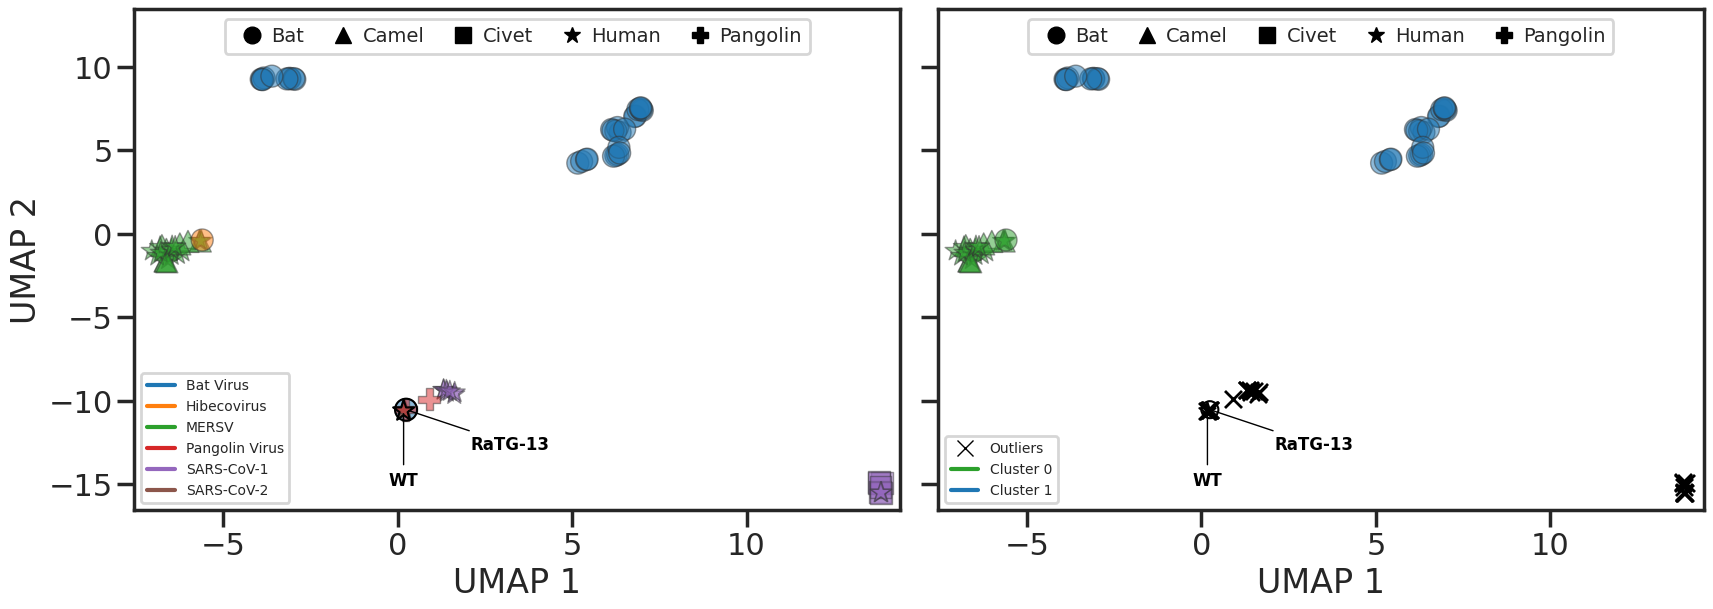

Predicted Clusters,-1,0,1
Ground Truth,,,
Bat Virus,3.03,0.0,96.97
Hibecovirus,0.00,100.0,0.00
MERSV,0.00,100.0,0.00
Pangolin Virus,100.00,0.0,0.00
SARS-CoV-1,100.00,0.0,0.00
SARS-CoV-2,100.00,0.0,0.00


In [516]:
best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

annotation_labels = {
    'MN908947':(0,-50),
    'MN996532':(75,-25),
    # 'KF569996':(-75,0),
    # 'KT444582':(-10,-40),
    # 'KF367457':(-5,100),
    # 'KY417151':(-50,55)
}

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as,
    plot_dir=os.path.join(plot_dir, version_dir),
    annotation_labels=annotation_labels,
    x_min_width_buffer=0.5, x_max_width_buffer=0.5, y_min_height_buffer=1, y_max_height_buffer=4, 
    color_map="tab10", 
    cluster_color_palette_order=[2, 0]
)
display(truth_table_percent)

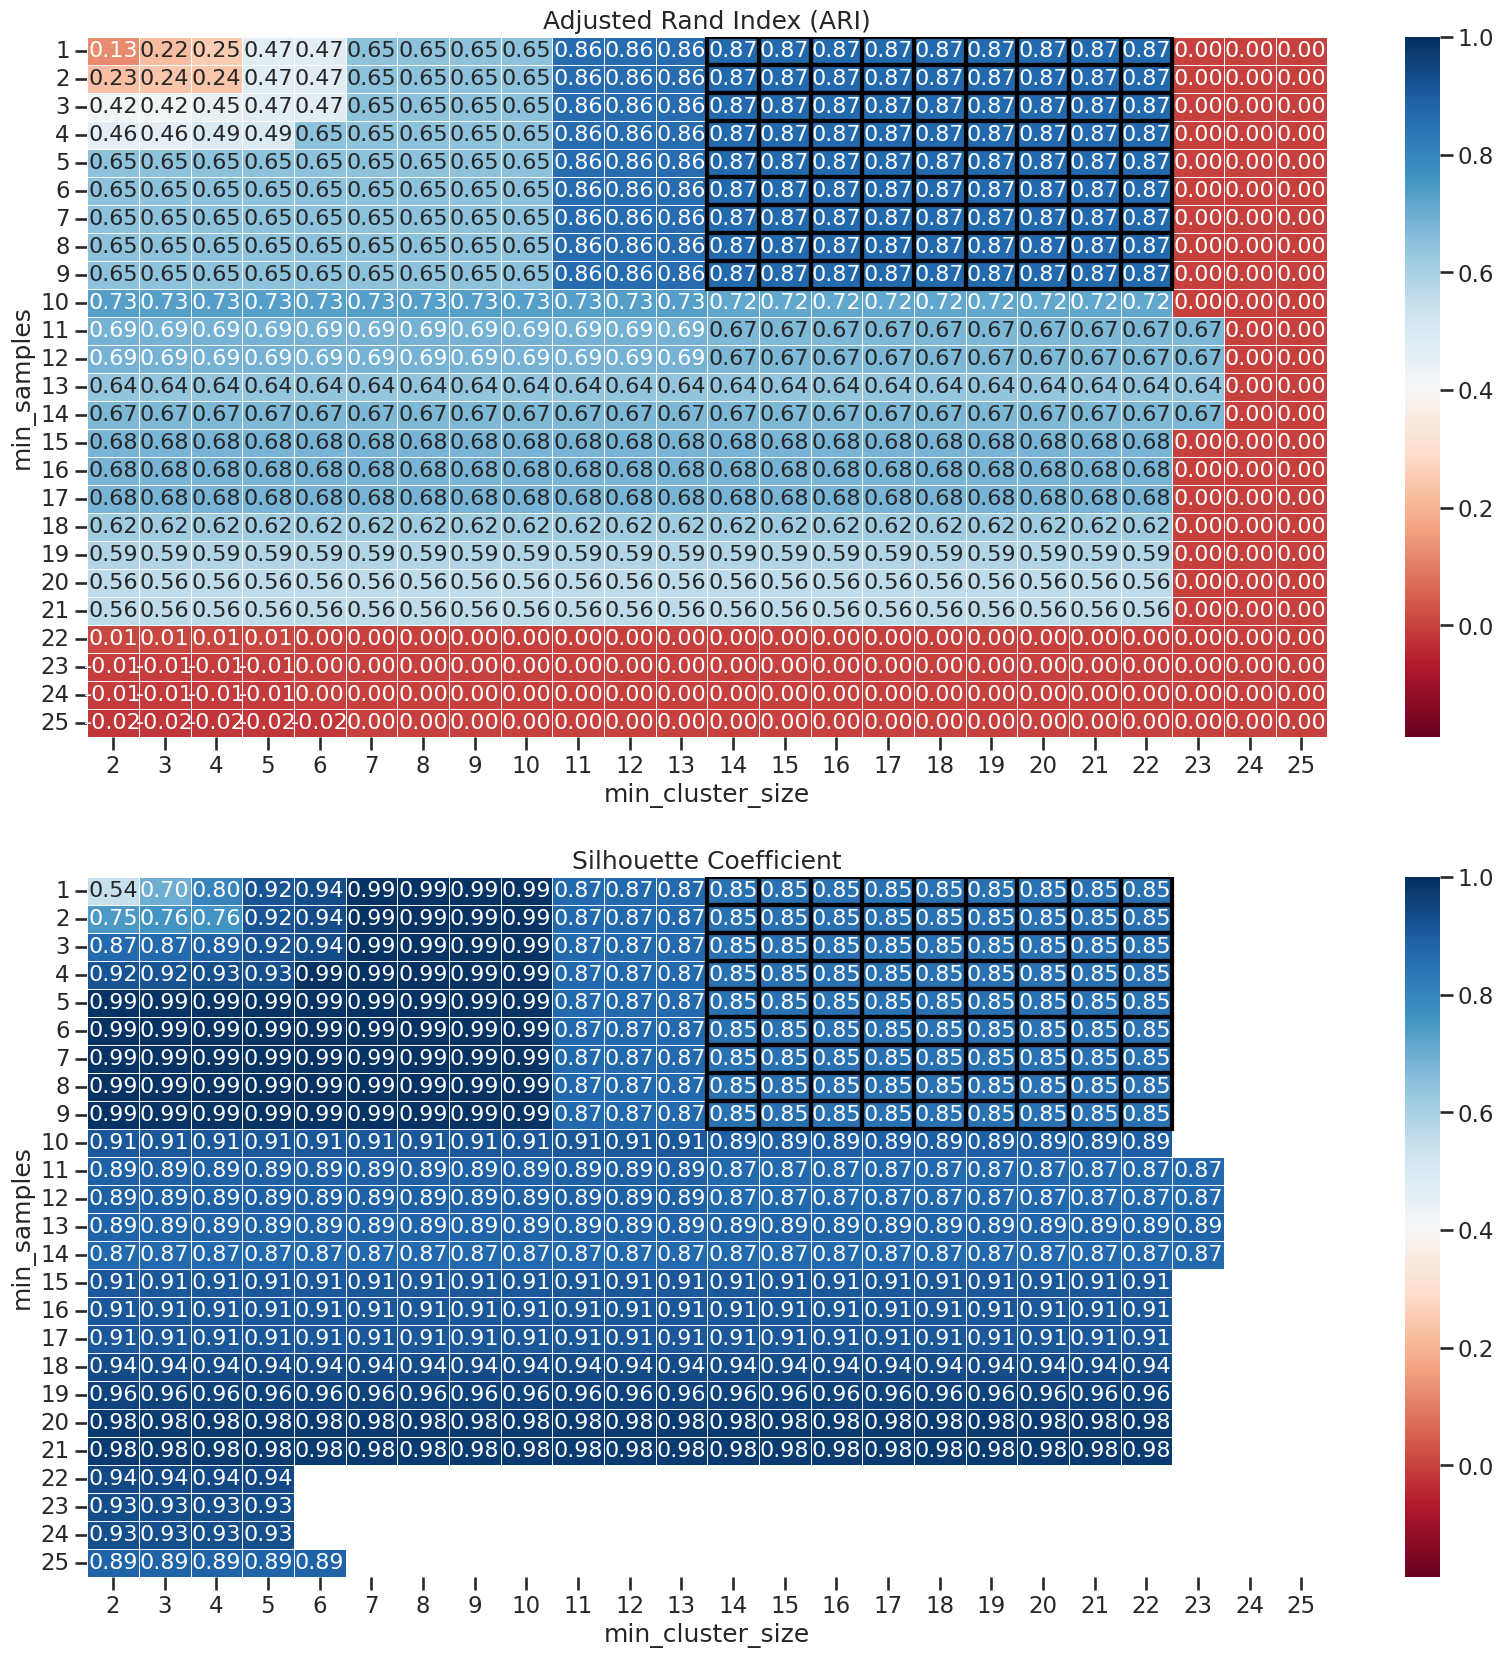

In [517]:
best_df = scored_results_df[
    (scored_results_df["n_neighbors"] == n_neighbors) &
    (scored_results_df["min_dist"] == min_dist)
].copy()

ari_sc_heatmap(
    best_df,
    parquet_file,  
    plot_dir=os.path.join(plot_dir, version_dir),
)

---
## IGNORE

### Best result within each UMAP setting, based on ari_noise_score, ARI, and SC

In [518]:
summary_df = (
    scored_results_df
    .sort_values(
        by=["ari_noise_score", "ari", "silhouette"],
        ascending=[False, False, False]
    )
    .groupby(["n_neighbors", "min_dist"], as_index=False)
    .first()
    .rename(columns={
        "ari": "best_ari",
        "silhouette": "best_silhouette",
        "n_clusters": "best_n_clusters",
        "noise_fraction": "best_noise_fraction",
        "ari_noise_score": "best_ari_noise_score",
        "ari_noise_silhouette_score": "best_ari_noise_silhouette_score",
        "ari_noise_silhouette_clusterct_score": "best_ari_noise_silhouette_clusterct_score",
        "min_samples": "best_min_samples",
        "min_cluster_size": "best_min_cluster_size",
    })
)

print("Best overall UMAP + HDBSCAN settings (top 5):")
top5 = (
    summary_df
    .sort_values(
        by=["best_ari_noise_score", "best_ari", "best_silhouette"],
        ascending=[False, False, False]
    )
    .head(5)
    .reset_index(drop=True)
)
display(top5)

Best overall UMAP + HDBSCAN settings (top 5):


,n_neighbors,min_dist,best_min_samples,best_min_cluster_size,best_ari,best_noise_fraction,best_silhouette,best_n_clusters,best_ari_noise_score
0,71,0.75,1,3,0.851129,0.0,0.498638,3,0.851129
1,55,0.15,2,11,0.846614,0.0,0.690966,3,0.846614
2,55,0.00,1,11,0.743053,0.0,0.791515,4,0.743053
3,40,0.10,1,12,0.743053,0.0,0.191738,4,0.743053
4,3,0.50,1,13,0.731332,0.0,0.855519,3,0.731332


UMAP | n_neighbors = 71, min_dist = 0.75
min_samples = 1, min_cluster_size = 3: ARI = 0.85, Silhouette = 0.50, Clusters = 3, Noise = 0.00%
3: [0 1 2]


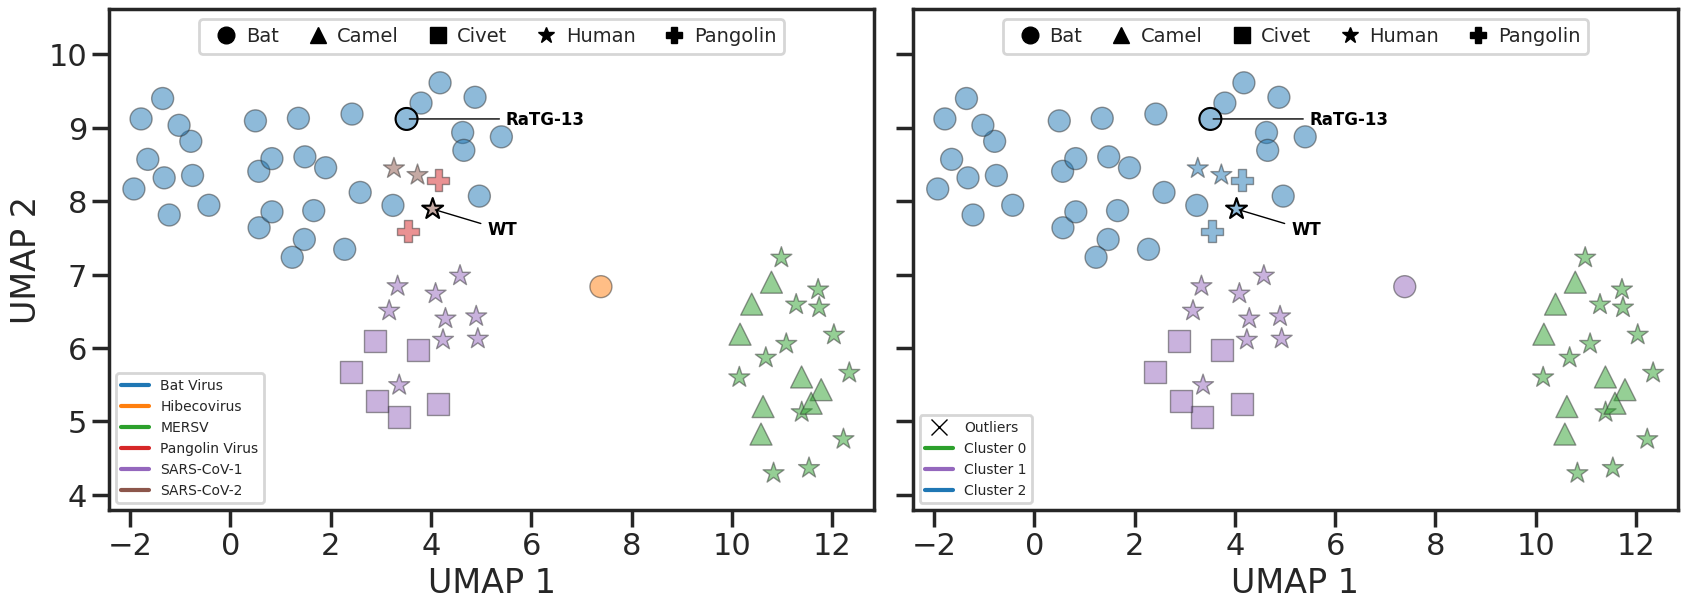

Predicted Clusters,0,1,2
Ground Truth,,,
Bat Virus,0.0,0.0,100.0
Hibecovirus,0.0,100.0,0.0
MERSV,100.0,0.0,0.0
Pangolin Virus,0.0,0.0,100.0
SARS-CoV-1,0.0,100.0,0.0
SARS-CoV-2,0.0,0.0,100.0


In [519]:
best = top5.iloc[0]
n_neighbors = int(best["n_neighbors"])
min_dist = best["min_dist"]
print(f"UMAP | n_neighbors = {n_neighbors}, min_dist = {min_dist}")

plot_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/plots"
parquet_dir = "/panfs/biopan03/prime_ml/prime/notebooks/clustering/blackwell/betacov/parquets"
parquet_file = os.path.join(parquet_dir, version_dir, f"{version_prefix}.umap-nneighbors{n_neighbors}_mindist{min_dist}.parquet")

min_samples = int(best["best_min_samples"])
min_cluster_size = int(best["best_min_cluster_size"])
plot_df, truth_table_percent, save_as = get_hdbscan_values(parquet_file, min_samples, min_cluster_size)

save_as.replace(".parquet", ".best_ari_noise_score.parquet")

unique_clusters = np.unique(plot_df["Cluster"])
non_noise_clusters = unique_clusters[unique_clusters != -1]
print(f"{len(non_noise_clusters)}: {non_noise_clusters}") # use this for cluster_color_palette_order if you want to set it

annotation_labels = {
    'MN908947':(50,-15),
    'MN996532':(100,0),
    # 'KF569996':(-75,0),
    # 'KT444582':(-10,-40),
    # 'KF367457':(-5,100),
    # 'KY417151':(-50,55)
}

# Call the function
plot_groundtruth_prediction_1x2(
    plot_df, save_as,
    plot_dir=os.path.join(plot_dir, version_dir),
    annotation_labels=annotation_labels,
    x_min_width_buffer=0.5, x_max_width_buffer=0.5, y_min_height_buffer=0.5, y_max_height_buffer=1, 
    color_map="tab10", 
    cluster_color_palette_order=[2, 4, 0]
)
display(truth_table_percent)

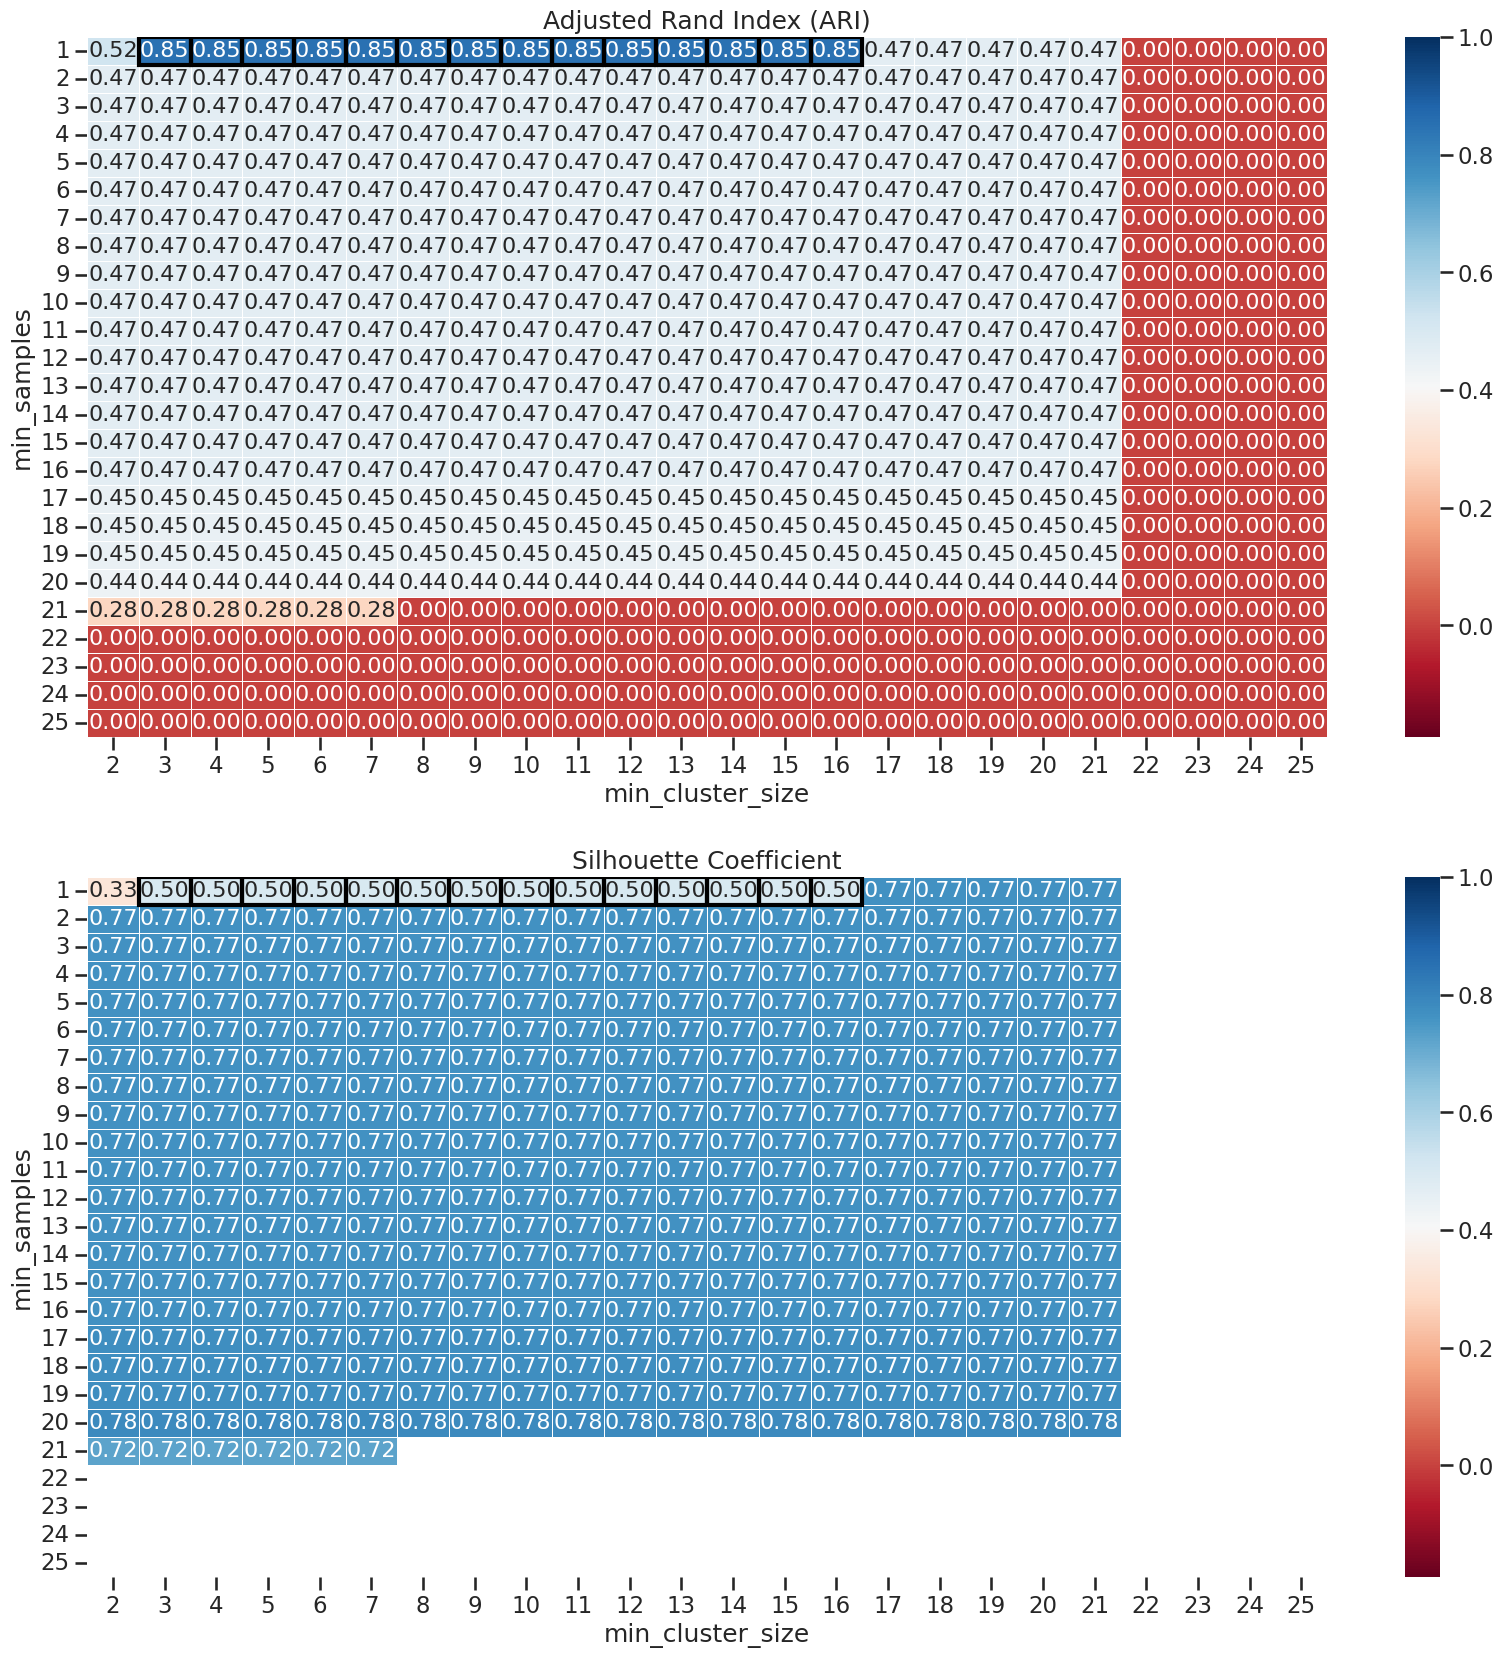

In [520]:
best_df = scored_results_df[
    (scored_results_df["n_neighbors"] == n_neighbors) &
    (scored_results_df["min_dist"] == min_dist)
].copy()

ari_sc_heatmap(
    best_df,
    parquet_file,  
    plot_dir=os.path.join(plot_dir, version_dir),
)